In [1]:
import nltk
nltk.download('gutenberg')
from nltk.corpus import gutenberg
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


In [2]:
data = gutenberg.raw('shakespeare-hamlet.txt')

with open('hamlet.txt', 'w') as f:
    f.write(data)

In [3]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from sklearn.model_selection import train_test_split

In [4]:
with open('hamlet.txt', 'r') as f:
  text = f.read().lower()

tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])
total_words = len(tokenizer.word_index) + 1
total_words

4818

In [5]:
tokenizer.word_index

{'the': 1,
 'and': 2,
 'to': 3,
 'of': 4,
 'i': 5,
 'you': 6,
 'a': 7,
 'my': 8,
 'it': 9,
 'in': 10,
 'that': 11,
 'ham': 12,
 'is': 13,
 'not': 14,
 'his': 15,
 'this': 16,
 'with': 17,
 'your': 18,
 'but': 19,
 'for': 20,
 'me': 21,
 'lord': 22,
 'as': 23,
 'what': 24,
 'he': 25,
 'be': 26,
 'so': 27,
 'him': 28,
 'haue': 29,
 'king': 30,
 'will': 31,
 'no': 32,
 'our': 33,
 'we': 34,
 'on': 35,
 'are': 36,
 'if': 37,
 'all': 38,
 'then': 39,
 'shall': 40,
 'by': 41,
 'thou': 42,
 'come': 43,
 'or': 44,
 'hamlet': 45,
 'good': 46,
 'do': 47,
 'hor': 48,
 'her': 49,
 'let': 50,
 'now': 51,
 'thy': 52,
 'how': 53,
 'more': 54,
 'they': 55,
 'from': 56,
 'enter': 57,
 'at': 58,
 'was': 59,
 'oh': 60,
 'like': 61,
 'most': 62,
 'there': 63,
 'well': 64,
 'know': 65,
 'selfe': 66,
 'would': 67,
 'them': 68,
 'loue': 69,
 'may': 70,
 "'tis": 71,
 'vs': 72,
 'sir': 73,
 'qu': 74,
 'which': 75,
 'did': 76,
 'why': 77,
 'laer': 78,
 'giue': 79,
 'thee': 80,
 'ile': 81,
 'must': 82,
 'hath': 

In [6]:
input_sequence = []
for line in text.split('\n'):
  token_list = tokenizer.texts_to_sequences([line])[0]
  for i in range(1, len(token_list)):
    n_gram_sequence = token_list[:i+1]
    input_sequence.append(n_gram_sequence)

In [7]:
max_sequence_len = max([len(x) for x in input_sequence])
max_sequence_len

14

In [8]:
input_sequence = np.array(pad_sequences(input_sequence, maxlen = max_sequence_len, padding='pre'))
input_sequence

array([[   0,    0,    0, ...,    0,    1,  687],
       [   0,    0,    0, ...,    1,  687,    4],
       [   0,    0,    0, ...,  687,    4,   45],
       ...,
       [   0,    0,    0, ...,    4,   45, 1047],
       [   0,    0,    0, ...,   45, 1047,    4],
       [   0,    0,    0, ..., 1047,    4,  193]], dtype=int32)

In [9]:
import tensorflow as tf

X, y = input_sequence[:, :-1], input_sequence[:, -1]
y = tf.keras.utils.to_categorical(y, num_classes=total_words) # wherever presetn that will be 1 remaning all will be 0.

In [10]:
X

array([[   0,    0,    0, ...,    0,    0,    1],
       [   0,    0,    0, ...,    0,    1,  687],
       [   0,    0,    0, ...,    1,  687,    4],
       ...,
       [   0,    0,    0, ...,  687,    4,   45],
       [   0,    0,    0, ...,    4,   45, 1047],
       [   0,    0,    0, ...,   45, 1047,    4]], dtype=int32)

In [11]:
y

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=11, restore_best_weights = True)

In [14]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GRU

# train lstm model
model_lstm = Sequential()
model_lstm.add(Embedding(total_words, 150, input_length=max_sequence_len-1))
model_lstm.add(LSTM(150, return_sequences=True))
model_lstm.add(Dropout(0.3))
model_lstm.add(LSTM(100))
model_lstm.add(Dropout(0.3))
# model.add(LSTM(50))
model_lstm.add(Dense(total_words, activation='softmax'))

model_lstm.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Ensure the model is built so summary shows parameter counts
model_lstm.build(input_shape=(None, max_sequence_len-1))
model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 13, 150)        │       722,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 13, 150)        │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 150)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │       100,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4818)           │       486,618 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,490,318 (5.69 MB)

 Trainable params: 1,490,318 (5.69 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# history = model.fit(X_train, y_train, epochs=150, batch_size=64, validation_data=(X_test, y_test), verbose=1, callbacks=[early_stop])
history = model_lstm.fit(X_train, y_train, epochs=100, batch_size=64, validation_data=(X_test, y_test), verbose=1)

Epoch 1/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.0330 - loss: 6.9231 - val_accuracy: 0.0334 - val_loss: 6.6687
Epoch 2/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.0344 - loss: 6.5262 - val_accuracy: 0.0389 - val_loss: 6.7272
Epoch 3/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0390 - loss: 6.4328 - val_accuracy: 0.0396 - val_loss: 6.7854
Epoch 4/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0445 - loss: 6.3504 - val_accuracy: 0.0420 - val_loss: 6.8229
Epoch 5/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.0492 - loss: 6.2549 - val_accuracy: 0.0490 - val_loss: 6.8256
Epoch 6/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0548 - loss: 6.1494 - val_accuracy: 0.0490 - val_loss: 6.8635
Epoch 7/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0549 - loss: 6.0444 - val_accuracy: 0.0493 - val_loss: 6.8965
Epoch 8/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.0592 - loss: 5.9439 -

In [16]:
from tensorflow.keras.layers import GRU

# Build GRU model (Matching the complexity of the LSTM)
model_gru = Sequential()
model_gru.add(Embedding(total_words, 150)) # Removed input_length as it's deprecated
model_gru.add(GRU(150, return_sequences=True))
model_gru.add(Dropout(0.2))
model_gru.add(GRU(100))
model_gru.add(Dropout(0.2))
model_gru.add(Dense(total_words, activation="softmax"))

model_gru.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_gru.build(input_shape=(None, max_sequence_len-1))
model_gru.summary()

# Train GRU
history_gru = model_gru.fit(X_train, y_train, epochs=100, batch_size=64, validation_data=(X_test, y_test), verbose=1)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 13, 150)        │       722,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 13, 150)        │       135,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 13, 150)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 100)            │        75,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4818)           │       486,618 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,420,818 (5.42 MB)

 Trainable params: 1,420,818 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.0323 - loss: 6.9760 - val_accuracy: 0.0334 - val_loss: 6.8327
Epoch 2/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0337 - loss: 6.5849 - val_accuracy: 0.0357 - val_loss: 6.7757
Epoch 3/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.0492 - loss: 6.3576 - val_accuracy: 0.0521 - val_loss: 6.7152
Epoch 4/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0602 - loss: 6.1428 - val_accuracy: 0.0593 - val_loss: 6.6936
Epoch 5/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.0756 - loss: 5.9060 - val_accuracy: 0.0647 - val_loss: 6.7136
Epoch 6/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.0886 - loss: 5.6724 - val_accuracy: 0.0676 - val_loss: 6.7848
Epoch 7/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.0988 - loss: 5.4497 - val_accuracy: 0.0701 - val_loss: 6.8520
Epoch 8/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.1081 - loss: 5.2372 - 

In [17]:
# Function to predict the next word
def predict_next_word(model, tokenizer, text, max_sequence_len):
    token_list = tokenizer.texts_to_sequences([text])[0]
    if len(token_list) >= max_sequence_len:
        token_list = token_list[-(max_sequence_len-1):]  # Ensure the sequence length matches max_sequence_len-1
    token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
    predicted = model.predict(token_list, verbose=0)
    predicted_word_index = np.argmax(predicted, axis=1)
    for word, index in tokenizer.word_index.items():
        if index == predicted_word_index:
            return word
    return None

In [18]:
input_text="To be or not to be"
print(f"Input text:{input_text}")
max_sequence_len = model_lstm.input_shape[1]+1
next_word=predict_next_word(model_lstm,tokenizer,input_text,max_sequence_len)
print(f"Next Word Prediction using LSTM:{next_word}")

Input text:To be or not to be
Next Word Prediction using LSTM:of


In [19]:
import pickle

# Save models in the recommended .keras format
model_lstm.save("final_next_word_lstm.keras")
model_gru.save("final_next_word_gru.keras")

# Save the tokenizer
with open('tokenizer_final.pickle','wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [20]:
input_text="  Barn. Last night of all,When yond same"
print(f"Input text:{input_text}")
max_sequence_len = model_gru.input_shape[1]+1
next_word=predict_next_word(model_gru,tokenizer,input_text,max_sequence_len)
print(f"Next Word Prediction using GRU: {next_word}")

Input text:  Barn. Last night of all,When yond same
Next Word Prediction using GRU: spirit


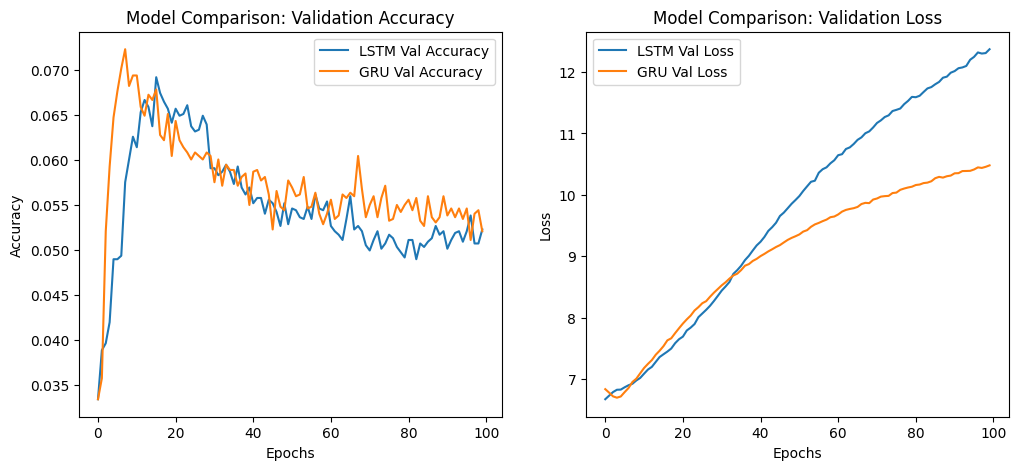

In [21]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['val_accuracy'], label='LSTM Val Accuracy')
plt.plot(history_gru.history['val_accuracy'], label='GRU Val Accuracy')
plt.title('Model Comparison: Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['val_loss'], label='LSTM Val Loss')
plt.plot(history_gru.history['val_loss'], label='GRU Val Loss')
plt.title('Model Comparison: Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()